In [1]:
import numpy as np
from sklearn.dummy import DummyRegressor
from sklearn.datasets import load_diabetes
from sklearn.model_selection import KFold, cross_val_score, cross_validate, learning_curve, LeaveOneOut, LeavePOut
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.kernel_ridge import KernelRidge
import matplotlib.pyplot as plt

In [2]:
# start with KFold cross validation (cv), which is the most common type of cross validation
# compare different models using cross validation
# remember to set random_state for reproducibility, and shuffle=True to shuffle the data before splitting into folds

cv = KFold(n_splits=5) # 5-fold cross validation, no shuffling

model_dummy = DummyRegressor(strategy="mean") # baseline model, predicts the mean of the training data
model1 = KernelRidge(kernel='rbf')
model2 = RandomForestRegressor(random_state=0)
model3 = HistGradientBoostingRegressor(random_state=0)
# KRR is a regression model used often in materials science, can use as a baseline model.
    # choose kernel='rbf' for non-linear datasets, kernel='linear' for linear datasets.
    # Note the toy dataset is not a materials science dataset, but we can still use it to demonstrate cross validation.
# Random Forest is a tree-based model, which is often used in materials science and performs better than KRR for non-linear datasets (?)
# HistGradientBoostingRegressor is a gradient boosting model, related to Random forest but generally performs better than Random Forest.
    # It is also often used in materials science.

In [3]:
# pick a toy dataset to work with
# return_X_y simply returns a feature array and a target vector/array instead of a sklearn Bunch object
# can use as_dataframe=True to return a dataframe instead of numpy arrays

X, y = load_diabetes(return_X_y=True)
y.std()

77.00574586945044

In [4]:
# compare the models using cross validation

# Dummy Regressor
res_dummy = cross_validate(model_dummy, X, y, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"Dummy Regressor scores:")
print(f"    MAE: {res_dummy['test_score'].mean():.3f} +/- {res_dummy['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_dummy['test_score'], 3)}")
print(f"    runtime: {res_dummy['fit_time'].sum() + res_dummy['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# KRR
res_KRR = cross_validate(model1, X, y, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"KRR scores:")
print(f"    MAE: {res_KRR['test_score'].mean():.3f} +/- {res_KRR['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_KRR['test_score'], 3)}")
print(f"    runtime: {res_KRR['fit_time'].sum() + res_KRR['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# Random Forest
res_RF = cross_validate(model2, X, y, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"Random Forest scores:")
print(f"    MAE: {res_RF['test_score'].mean():.3f} +/- {res_RF['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_RF['test_score'], 3)}")
print(f"    runtime: {res_RF['fit_time'].sum() + res_RF['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# HistGradientBoostingRegressor
res_HGB = cross_validate(model3, X, y, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"HistGradientBoostingRegressor scores:")
print(f"    MAE: {res_HGB['test_score'].mean():.3f} +/- {res_HGB['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_HGB['test_score'], 3)}")
print(f"    runtime: {res_HGB['fit_time'].sum() + res_HGB['score_time'].sum():.2f} s total")
print('----------------------------------------------')

Dummy Regressor scores:
    MAE: -66.046 +/- 3.475
    per-fold: [-60.953 -68.322 -67.136 -63.264 -70.554]
    runtime: 0.00 s total
----------------------------------------------
KRR scores:
    MAE: -57.435 +/- 3.149
    per-fold: [-53.459 -57.791 -60.004 -54.319 -61.6  ]
    runtime: 0.06 s total
----------------------------------------------
Random Forest scores:
    MAE: -46.992 +/- 1.775
    per-fold: [-45.217 -45.012 -49.149 -46.621 -48.963]
    runtime: 0.91 s total
----------------------------------------------
HistGradientBoostingRegressor scores:
    MAE: -46.997 +/- 2.265
    per-fold: [-43.531 -45.831 -50.357 -47.344 -47.923]
    runtime: 1.79 s total
----------------------------------------------


In [5]:
# we see that Random Forest and HistGradientBoostingRegressor perform better than KRR, 
# but RF and HGB results are indistinguishable from each other.
# KRR, Random Forest, and HistGradientBoostingRegressor all perform reasonably well compared to the Dummy Regressor.

In [6]:
# Because RF and HGB are indistinguishable, we can choose either one to use for the next step of cross validation
# I pick RF because it is a simpler model with fewer moving parts.
# It is also faster to train and predict than HGB, which is important for large datasets.

cv1 = KFold(n_splits=5) # 5-fold cross validation, no shuffling
cv2 = KFold(n_splits=5, shuffle=True, random_state=0) # 5-fold cross validation, with shuffling
cv3 = KFold(n_splits=20) # 20-fold cross validation, no shuffling
cv4 = LeaveOneOut() # leave-one-out cross validation
cv5 = LeavePOut(p=2) # leave-two-out cross validation

# CVs to compare:
    # cv1: 5-fold cross validation, no shuffling
    # cv2: 5-fold cross validation, with shuffling
    # cv3: 20-fold cross validation, no shuffling
    # cv4: leave-one-out cross validation
    # cv5: leave-two-out cross validation

# model choice: Random Forest Regressor
model = RandomForestRegressor(random_state=0)

In [7]:
# compare different cross validation methods

# 5-fold cross validation, no shuffling
res_cv1 = cross_validate(model, X, y, cv=cv1, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"5-fold cross validation, no shuffling scores:")
print(f"    MAE: {res_cv1['test_score'].mean():.3f} +/- {res_cv1['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_cv1['test_score'], 3)}")
print(f"    runtime: {res_cv1['fit_time'].sum() + res_cv1['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# 5-fold cross validation, with shuffling
res_cv2 = cross_validate(model, X, y, cv=cv2, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"5-fold cross validation, with shuffling scores:")
print(f"    MAE: {res_cv2['test_score'].mean():.3f} +/- {res_cv2['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_cv2['test_score'], 3)}")
print(f"    runtime: {res_cv2['fit_time'].sum() + res_cv2['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# 20-fold cross validation, no shuffling
res_cv3 = cross_validate(model, X, y, cv=cv3, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"20-fold cross validation, no shuffling scores:")
print(f"    MAE: {res_cv3['test_score'].mean():.3f} +/- {res_cv3['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_cv3['test_score'], 3)}")
print(f"    runtime: {res_cv3['fit_time'].sum() + res_cv3['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# leave-one-out cross validation
res_cv4 = cross_validate(model, X, y, cv=cv4, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"Leave-one-out cross validation scores:")
print(f"    MAE: {res_cv4['test_score'].mean():.3f} +/- {res_cv4['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_cv4['test_score'], 3)}")
print(f"    runtime: {res_cv4['fit_time'].sum() + res_cv4['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# # leave-two-out cross validation
# res_cv5 = cross_validate(model, X, y, cv=cv5, scoring='neg_mean_absolute_error', return_train_score=True)
# print(f"Leave-two-out cross validation scores:")
# print(f"    MAE: {res_cv5['test_score'].mean():.3f} +/- {res_cv5['test_score'].std():.3f}")
# print(f"    per-fold: {np.round(res_cv5['test_score'], 3)}")
# print(f"    runtime: {res_cv5['fit_time'].sum() + res_cv5['score_time'].sum():.2f} s total")
# print('----------------------------------------------')

5-fold cross validation, no shuffling scores:
    MAE: -46.992 +/- 1.775
    per-fold: [-45.217 -45.012 -49.149 -46.621 -48.963]
    runtime: 0.93 s total
----------------------------------------------
5-fold cross validation, with shuffling scores:
    MAE: -47.084 +/- 2.816
    per-fold: [-47.659 -44.577 -43.133 -49.794 -50.259]
    runtime: 0.93 s total
----------------------------------------------
20-fold cross validation, no shuffling scores:
    MAE: -47.085 +/- 6.346
    per-fold: [-51.533 -44.272 -38.83  -48.864 -43.557 -43.777 -57.301 -39.018 -47.86
 -53.713 -44.919 -52.933 -48.735 -40.65  -44.892 -40.617 -54.178 -61.164
 -37.555 -47.336]
    runtime: 5.09 s total
----------------------------------------------
Leave-one-out cross validation scores:
    MAE: -46.918 +/- 34.399
    per-fold: [-7.5920e+01 -1.7390e+01 -2.1400e+01 -2.8840e+01 -2.8760e+01 -1.7390e+01
 -6.8240e+01 -9.8680e+01 -3.2960e+01 -1.6098e+02 -1.0390e+01 -1.0604e+02
 -8.5260e+01 -5.1900e+00 -1.5760e+01 -1.964

In [8]:
# CV comparison shows indistinguishable MAE differences between 5-fold CV with and without shuffling, 20-fold CV, and Leave-One-Out CV.
# LOO is the most computationally expensive, so it is not practical for large datasets.
    #  LOO has very high variance, this could be due to the lack of correlation in the toy dataset we used

# realistically, we would move forward with 5-fold CV with or without shuffling based on our results on the diabetes dataset

Text(0.5, 1.0, 'Comparison of Cross Validation Methods')

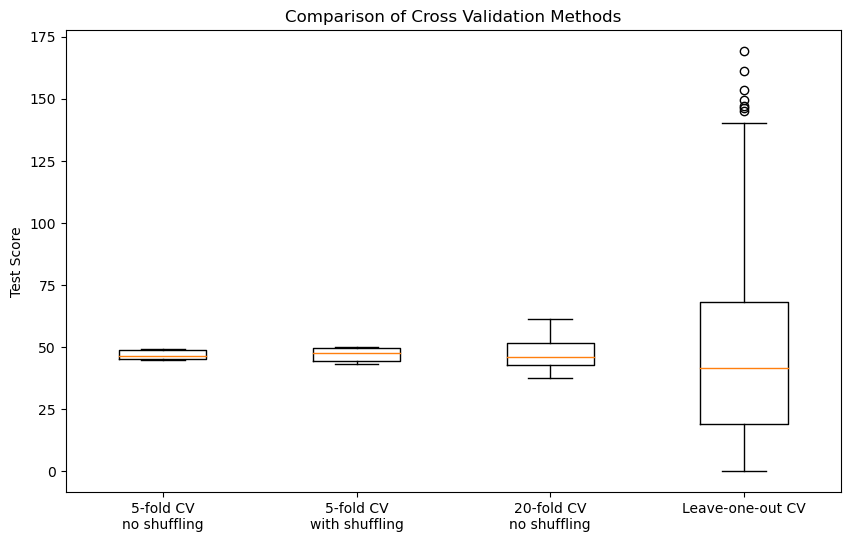

In [9]:
plt.figure(figsize=(10, 6))
plt.boxplot([-res_cv1['test_score'], -res_cv2['test_score'], -res_cv3['test_score'], -res_cv4['test_score']])
plt.xticks([1, 2, 3, 4], ['5-fold CV\nno shuffling', '5-fold CV\nwith shuffling', '20-fold CV\nno shuffling', 'Leave-one-out CV'])
plt.ylabel('Test Score')
plt.title('Comparison of Cross Validation Methods')

# Time to apply this to my own dataset

In [10]:
import pandas as pd

In [26]:
# this dataset is a composition feature matrix for B-site alloy halide perovskites which I generated using matminer and my PhD research.
# this dataset does not contain any dos-related features
# there are multiple possible targets to predict, Eg, dHf, and dHd. For this notebook, we will focus on predicting Eg.

my_df = pd.read_parquet('parquet/composition_feature_matrix.parquet')

In [27]:
# these are the non-feature columns in the dataframe, which we will drop before training the model
non_feature_cols = ['formula', 'alloy_id', 'A1', 'A2', 'B1', 'B2', 'X', 'is_alloy', 'x_frac', 'Eg', 'dHf', 'dHd']

In [28]:
# convert the dataframe to a numpy array for use with sklearn
X = my_df.drop(columns=non_feature_cols).values

# grab the target column, Eg, and convert it to a numpy array
y = my_df['Eg'].values

In [29]:
# KFold cross validation (cv)
# compare different models using cross validation
# remember to set random_state for reproducibility, and shuffle=True to shuffle the data before splitting into folds

cv = KFold(n_splits=5) # 5-fold cross validation, no shuffling

model_dummy = DummyRegressor(strategy="mean") # baseline model, predicts the mean of the training data
model1 = KernelRidge(kernel='rbf')
model2 = RandomForestRegressor(random_state=0)
model3 = HistGradientBoostingRegressor(random_state=0)
# KRR is a regression model used often in materials science, can use as a baseline model.
    # choose kernel='rbf' for non-linear datasets, kernel='linear' for linear datasets.
    # Note the toy dataset is not a materials science dataset, but we can still use it to demonstrate cross validation.
# Random Forest is a tree-based model, which is often used in materials science and performs better than KRR for non-linear datasets (?)
# HistGradientBoostingRegressor is a gradient boosting model, related to Random forest but generally performs better than Random Forest.
    # It is also often used in materials science.

In [30]:
# compare the models using cross validation

# Dummy Regressor
res_dummy = cross_validate(model_dummy, X, y, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"Dummy Regressor scores:")
print(f"    MAE: {res_dummy['test_score'].mean():.3f} +/- {res_dummy['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_dummy['test_score'], 3)}")
print(f"    runtime: {res_dummy['fit_time'].sum() + res_dummy['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# KRR
res_KRR = cross_validate(model1, X, y, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"KRR scores:")
print(f"    MAE: {res_KRR['test_score'].mean():.3f} +/- {res_KRR['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_KRR['test_score'], 3)}")
print(f"    runtime: {res_KRR['fit_time'].sum() + res_KRR['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# Random Forest
res_RF = cross_validate(model2, X, y, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"Random Forest scores:")
print(f"    MAE: {res_RF['test_score'].mean():.3f} +/- {res_RF['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_RF['test_score'], 3)}")
print(f"    runtime: {res_RF['fit_time'].sum() + res_RF['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# HistGradientBoostingRegressor
res_HGB = cross_validate(model3, X, y, cv=cv, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"HistGradientBoostingRegressor scores:")
print(f"    MAE: {res_HGB['test_score'].mean():.3f} +/- {res_HGB['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_HGB['test_score'], 3)}")
print(f"    runtime: {res_HGB['fit_time'].sum() + res_HGB['score_time'].sum():.2f} s total")
print('----------------------------------------------')

Dummy Regressor scores:
    MAE: -1.257 +/- 0.028
    per-fold: [-1.251 -1.273 -1.249 -1.214 -1.299]
    runtime: 0.02 s total
----------------------------------------------
KRR scores:
    MAE: -0.860 +/- 0.115
    per-fold: [-0.805 -0.837 -0.825 -0.749 -1.081]
    runtime: 13.66 s total
----------------------------------------------
Random Forest scores:
    MAE: -0.077 +/- 0.016
    per-fold: [-0.071 -0.071 -0.064 -0.069 -0.108]
    runtime: 52.97 s total
----------------------------------------------
HistGradientBoostingRegressor scores:
    MAE: -0.086 +/- 0.014
    per-fold: [-0.079 -0.077 -0.077 -0.083 -0.114]
    runtime: 19.62 s total
----------------------------------------------


In [31]:
# like the toy dataset, we see that Random Forest and HistGradientBoostingRegressor perform better than KRR, 
# and RF and HGB results are indistinguishable from each other.
# Differently, KRR, Random Forest, and HistGradientBoostingRegressor all perform exceptionally well compared to the Dummy Regressor.
    # this is likely due to the fact that this dataset is deterministic, and the features are highly correlated with the target, Eg.

In [ ]:
# Because RF and HGB are indistinguishable, we can choose either one to use for the next step of cross validation
# I pick HGB this time because it is much faster based on the runtime reported in the above cell

cv1 = KFold(n_splits=5) # 5-fold cross validation, no shuffling
cv2 = KFold(n_splits=5, shuffle=True, random_state=0) # 5-fold cross validation, with shuffling
cv3 = KFold(n_splits=10) # 10-fold cross validation, no shuffling
cv4 = KFold(n_splits=10, shuffle=True, random_state=0) # 10-fold cross validation, with shuffling

# CVs to compare:
    # cv1: 5-fold cross validation, no shuffling
    # cv2: 5-fold cross validation, with shuffling
    # cv3: 10-fold cross validation, no shuffling
    # cv4: 10-fold cross validation, with shuffling
    # we are not going to use leave-one-out for this dataset because it is too large and would take too long to run.
# we are doing 10-fold CV instead of 20-fold CV because it is faster and the results are likely to be similar.


# model choice: Random Forest Regressor
model = HistGradientBoostingRegressor(random_state=0)

In [33]:
# compare different cross validation methods

# 5-fold cross validation, no shuffling
res_cv1 = cross_validate(model, X, y, cv=cv1, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"5-fold cross validation, no shuffling scores:")
print(f"    MAE: {res_cv1['test_score'].mean():.3f} +/- {res_cv1['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_cv1['test_score'], 3)}")
print(f"    runtime: {res_cv1['fit_time'].sum() + res_cv1['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# 5-fold cross validation, with shuffling
res_cv2 = cross_validate(model, X, y, cv=cv2, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"5-fold cross validation, with shuffling scores:")
print(f"    MAE: {res_cv2['test_score'].mean():.3f} +/- {res_cv2['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_cv2['test_score'], 3)}")
print(f"    runtime: {res_cv2['fit_time'].sum() + res_cv2['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# 10-fold cross validation, no shuffling
res_cv3 = cross_validate(model, X, y, cv=cv3, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"10-fold cross validation, no shuffling scores:")
print(f"    MAE: {res_cv3['test_score'].mean():.3f} +/- {res_cv3['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_cv3['test_score'], 3)}")
print(f"    runtime: {res_cv3['fit_time'].sum() + res_cv3['score_time'].sum():.2f} s total")
print('----------------------------------------------')

# 10-fold cross validation, with shuffling
res_cv4 = cross_validate(model, X, y, cv=cv4, scoring='neg_mean_absolute_error', return_train_score=True)
print(f"10-fold cross validation, with shuffling scores:")
print(f"    MAE: {res_cv4['test_score'].mean():.3f} +/- {res_cv4['test_score'].std():.3f}")
print(f"    per-fold: {np.round(res_cv4['test_score'], 3)}")
print(f"    runtime: {res_cv4['fit_time'].sum() + res_cv4['score_time'].sum():.2f} s total")
print('----------------------------------------------')

5-fold cross validation, no shuffling scores:
    MAE: -0.086 +/- 0.014
    per-fold: [-0.079 -0.077 -0.077 -0.083 -0.114]
    runtime: 20.50 s total
----------------------------------------------
5-fold cross validation, with shuffling scores:
    MAE: -0.074 +/- 0.002
    per-fold: [-0.072 -0.079 -0.074 -0.074 -0.072]
    runtime: 20.18 s total
----------------------------------------------
10-fold cross validation, no shuffling scores:
    MAE: -0.083 +/- 0.023
    per-fold: [-0.066 -0.073 -0.077 -0.076 -0.077 -0.074 -0.07  -0.087 -0.078 -0.149]
    runtime: 41.63 s total
----------------------------------------------
10-fold cross validation, with shuffling scores:
    MAE: -0.072 +/- 0.002
    per-fold: [-0.072 -0.07  -0.077 -0.075 -0.07  -0.071 -0.071 -0.073 -0.069 -0.074]
    runtime: 40.41 s total
----------------------------------------------


In [ ]:
# CV comparison shows indistinguishable MAE differences between 5-fold CV with shuffling, and 10-fold without shuffling
# shuffling appears to have provided meaningful improvement in MAE, boxplot shows that below
    # this could be due to the fact that my dataset is arranged such that non-alloys are at the bottom of the dataframe,
    # leading to large MAEs in the final folds of the unshuffled CV

# one thing we did not do is group or class our features during k-fold cross validation
    # this could be useful for datasets with distinct groups
    # e.g. we have metals and non-metals in the dataset, or we have alloys from the same alloy_id, 
    # and we want to make sure that the alloys from the same alloy_id are not all in the same fold

In [ ]:
print(my_df.iloc[-650:]['is_alloy'].value_counts())
# this shows that the last 650 rows of the dataframe are all non-alloys, which is why shuffling is important for this dataset.
    # performing a stratified or grouped k-fold cross validation would be a better approach for this dataset, but we will not do that in this notebook.
    # stratified and grouped cross validation will be happening in a future notebook

False    527
True     123
Name: is_alloy, dtype: int64


Text(0.5, 1.0, 'Comparison of Cross Validation Methods')

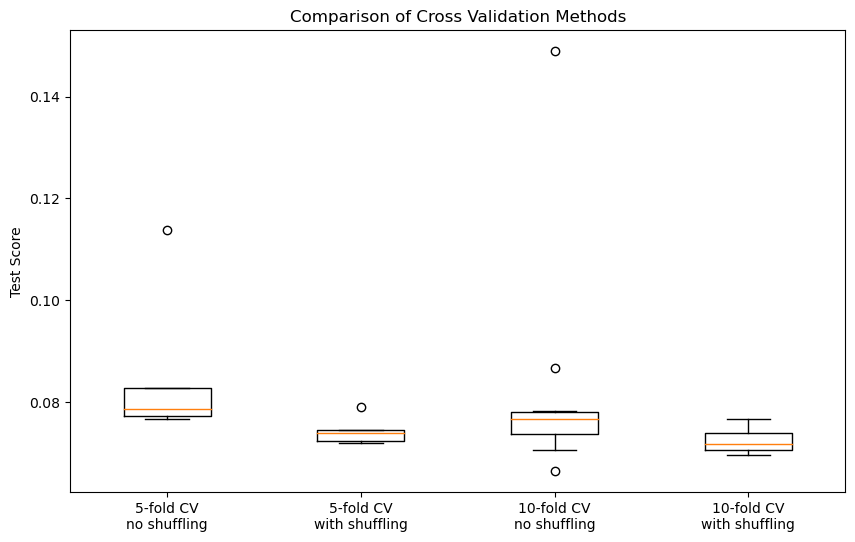

In [36]:
plt.figure(figsize=(10, 6))
plt.boxplot([-res_cv1['test_score'], -res_cv2['test_score'], -res_cv3['test_score'], -res_cv4['test_score']])
plt.xticks([1, 2, 3, 4], ['5-fold CV\nno shuffling', '5-fold CV\nwith shuffling', '10-fold CV\nno shuffling', '10-fold CV\nwith shuffling'])
plt.ylabel('Test Score')
plt.title('Comparison of Cross Validation Methods')